In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [11]:
data = pd.read_csv(
    r"C:\Users\admin\Desktop\DL\exp1\Developing-a-Neural-Network-Regression-Model\Exp-1.csv"
)

print(data.head())
print(data.columns)

   Input  Output
0      1       5
1      2       9
2      3      14
3      4      18
4      5      23
Index(['Input', 'Output'], dtype='str')


In [12]:
x = data[['Input']]
y = data[['Output']]

In [13]:
scale_x = MinMaxScaler()
scale_y = MinMaxScaler()

x_scaled = scale_x.fit_transform(x)
y_scaled = scale_y.fit_transform(y)

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x_scaled,
    y_scaled,
    test_size=0.2,
    random_state=42
)

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

In [16]:
class NeuralNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

In [17]:
model = NeuralNet()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

In [18]:
epochs = 1000

losses = []

for epoch in range(epochs):

    optimizer.zero_grad()

    prediction = model(X_train_tensor)

    loss = criterion(prediction, Y_train_tensor)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}  Loss = {loss.item():.6f}")

Epoch 50/1000  Loss = 0.001904
Epoch 100/1000  Loss = 0.000039
Epoch 150/1000  Loss = 0.000021
Epoch 200/1000  Loss = 0.000016
Epoch 250/1000  Loss = 0.000015
Epoch 300/1000  Loss = 0.000015
Epoch 350/1000  Loss = 0.000015
Epoch 400/1000  Loss = 0.000015
Epoch 450/1000  Loss = 0.000015
Epoch 500/1000  Loss = 0.000015
Epoch 550/1000  Loss = 0.000015
Epoch 600/1000  Loss = 0.000015
Epoch 650/1000  Loss = 0.000015
Epoch 700/1000  Loss = 0.000015
Epoch 750/1000  Loss = 0.000015
Epoch 800/1000  Loss = 0.000015
Epoch 850/1000  Loss = 0.000015
Epoch 900/1000  Loss = 0.000015
Epoch 950/1000  Loss = 0.000015
Epoch 1000/1000  Loss = 0.000015


In [19]:
model.eval()

with torch.no_grad():

    test_prediction = model(X_test_tensor)

    test_loss = criterion(test_prediction, Y_test_tensor)

print("Test Loss:", test_loss.item())

Test Loss: 0.0008204092155210674


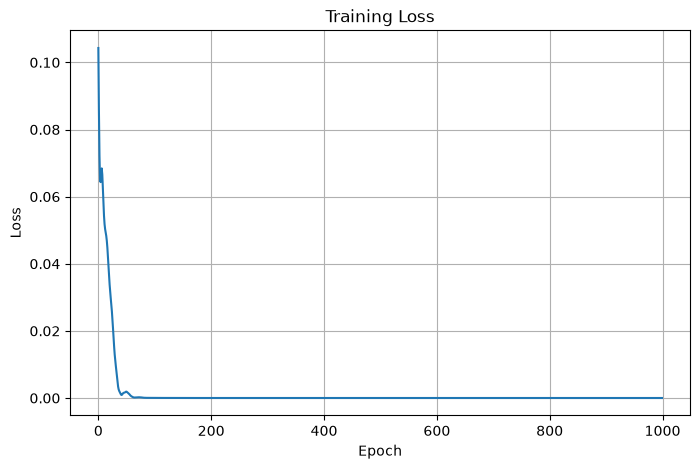

In [20]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [22]:
# Prediction
sample = pd.DataFrame([[16]], columns=["Input"])

sample_scaled = scale_x.transform(sample)

sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32)

with torch.no_grad():
    prediction = model(sample_tensor)

prediction_actual = scale_y.inverse_transform(prediction.numpy())

print(f"Predicted Output: {prediction_actual[0][0]:.2f}")

Predicted Output: 72.05
